In [1]:
# %% [markdown]
# # Bayesian Network Training with Explainability (Binary Dataset)
# 
# This notebook builds and trains a Bayesian network for disease prediction using a binary-formatted dataset. 
# It also includes an interactive terminal interface and an explainability module to understand *why* a prediction was made.
# 
# ## Dataset Format
# - **prognosis**: Disease name
# - **131 symptom columns**: Binary (0=absent, 1=present)
# 
# ## Network Structure
# We use a **Naive Bayes structure**:
# - Disease (prognosis) is the parent node
# - All symptoms are children of the disease node
# - Assumes conditional independence of symptoms given the disease

# %% [markdown]
# ## 1. Import Libraries

# %%
%pip install google-generativeai

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score
from google import genai
import pickle
import warnings
import os
import json
import google.generativeai as genai

warnings.filterwarnings('ignore')
print("✓ Libraries imported successfully!")

# %% [markdown]
# ## 2. Load Binary Dataset

# %%
# Load binary datasets (Adjust paths if running from a different directory)
df_train = pd.read_csv('../data/Training_binary.csv')
df_test = pd.read_csv('../data/Testing_binary.csv')

print(f"Training data: {df_train.shape}")
print(f"Testing data: {df_test.shape}")

# Get symptom columns (all columns except 'prognosis')
symptom_cols = [col for col in df_train.columns if col != 'prognosis']
print(f"\nSymptoms: {len(symptom_cols)}")
print(f"Diseases: {df_train['prognosis'].nunique()}")

# %% [markdown]
# ## 3. Build Bayesian Network Structure

# %%
# Create Naive Bayes structure: prognosis -> All Symptoms
edges = [('prognosis', symptom) for symptom in symptom_cols]

print(f"Creating Bayesian Network with {len(edges)} edges...")
model = DiscreteBayesianNetwork(edges)

print("\n✓ Bayesian Network structure created!")
print(f"  Nodes: {len(model.nodes())}")
print(f"  Edges: {len(model.edges())}")

# %% [markdown]
# ## 4. Visualize Network Structure 



Note: you may need to restart the kernel to use updated packages.
✓ Libraries imported successfully!
Training data: (4428, 132)
Testing data: (492, 132)

Symptoms: 131
Diseases: 41
Creating Bayesian Network with 131 edges...

✓ Bayesian Network structure created!
  Nodes: 132
  Edges: 131


C:\Users\hp\AppData\Local\Temp\ipykernel_12604\380464830.py:36: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


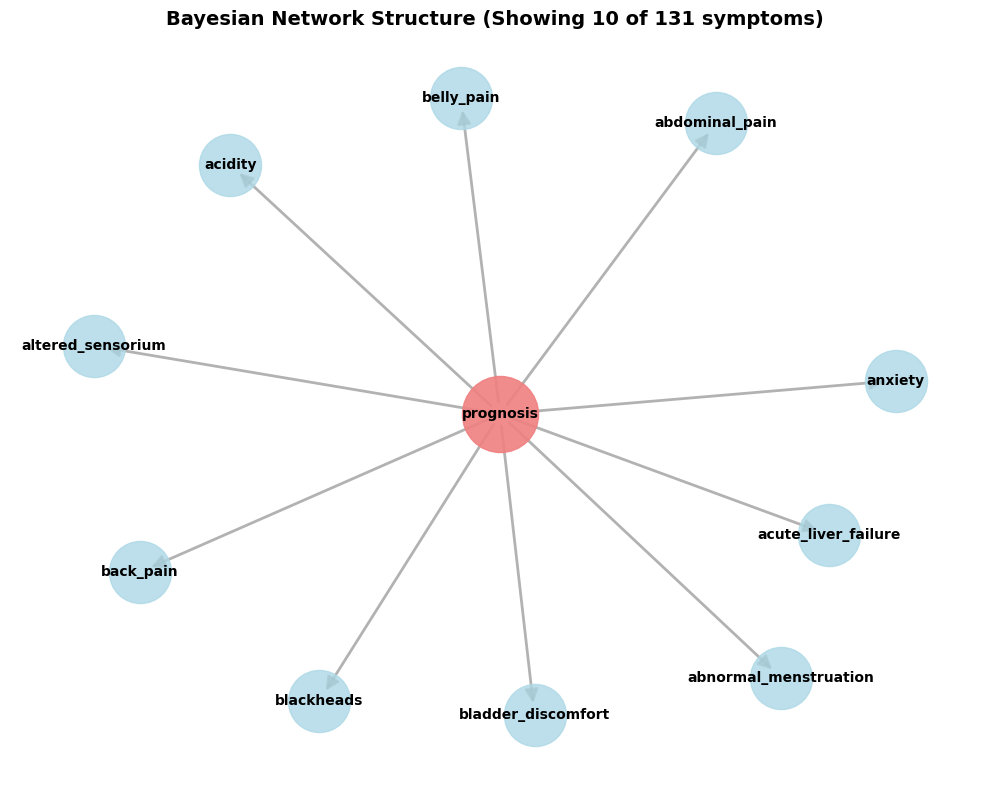

In [2]:
# %%
import networkx as nx

# Create a simplified network for visualization (first 10 symptoms only)
sample_symptoms = symptom_cols[:10]
sample_edges = [('prognosis', symptom) for symptom in sample_symptoms]

G = nx.DiGraph()
G.add_edges_from(sample_edges)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=2, iterations=50)

nx.draw_networkx_nodes(G, pos, nodelist=['prognosis'], node_color='lightcoral', node_size=3000, alpha=0.9)
nx.draw_networkx_nodes(G, pos, nodelist=sample_symptoms, node_color='lightblue', node_size=2000, alpha=0.8)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, width=2, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title(f"Bayesian Network Structure (Showing 10 of {len(symptom_cols)} symptoms)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Learn Parameters (CPTs)

# %%


In [3]:
print("Preparing data and learning Conditional Probability Tables (CPTs)...")

df_train_prepared = df_train.copy()
df_test_prepared = df_test.copy()

df_train_prepared['prognosis'] = df_train_prepared['prognosis'].astype('category')
df_test_prepared['prognosis'] = df_test_prepared['prognosis'].astype('category')

for col in symptom_cols:
    df_train_prepared[col] = df_train_prepared[col].astype(int)
    df_test_prepared[col] = df_test_prepared[col].astype(int)

model.fit(df_train_prepared, estimator=MaximumLikelihoodEstimator)
print("✓ Training complete!")

# %% [markdown]
# ## 6. Create Inference Engine

# %%


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'prognosis': 'C', 'abdominal_pain': 'N', 'abnormal_menstruation': 'N', 'acidity': 'N', 'acute_liver_failure': 'N', 'altered_sensorium': 'N', 'anxiety': 'N', 'back_pain': 'N', 'belly_pain': 'N', 'blackheads': 'N', 'bladder_discomfort': 'N', 'blister': 'N', 'blood_in_sputum': 'N', 'bloody_stool': 'N', 'blurred_and_distorted_vision': 'N', 'breathlessness': 'N', 'brittle_nails': 'N', 'bruising': 'N', 'burning_micturition': 'N', 'chest_pain': 'N', 'chills': 'N', 'cold_hands_and_feets': 'N', 'coma': 'N', 'congestion': 'N', 'constipation': 'N', 'continuous_feel_of_urine': 'N', 'continuous_sneezing': 'N', 'cough': 'N', 'cramps': 'N', 'dark_urine': 'N', 'dehydration': 'N', 'depression': 'N', 'diarrhoea': 'N', 'dischromic _patches': 'N', 'distention_of_abdomen': 'N', 'dizziness': 'N', 'drying_and_tingling_lips': 'N', 'enlarged_thyroid': 'N', 'excessive_hunger': 'N', 'extra_marital_contacts':

Preparing data and learning Conditional Probability Tables (CPTs)...
✓ Training complete!


In [4]:
inference = VariableElimination(model)
print("✓ Inference engine created (Variable Elimination)!")


✓ Inference engine created (Variable Elimination)!


In [5]:
# This function breaks down why a specific prediction was made by showing the conditional probability 
# of each provided symptom given the predicted disease: $P(Symptom=1 | Disease)$.

# %%
def explain_prediction(symptoms_dict, predicted_disease):
    """
    Explains the prediction by extracting the CPT values for the provided symptoms
    given the predicted disease.
    """
    print(f"\n--- Explanation for diagnosing: {predicted_disease} ---")
    
    # Get the prior probability of the disease P(Disease)
    disease_cpd = model.get_cpds('prognosis')
    disease_states = list(disease_cpd.state_names['prognosis'])
    if predicted_disease in disease_states:
        disease_idx = disease_states.index(predicted_disease)
        prior_prob = disease_cpd.values[disease_idx]
        print(f"Base probability (Prior) of {predicted_disease} in dataset: {prior_prob*100:.2f}%")
    
    print("\nHow your symptoms contributed (Conditional Probabilities):")
    print(f"If a patient has {predicted_disease}, the probability they exhibit these symptoms is:")
    
    contributions = []
    for symptom in symptoms_dict.keys():
        if symptoms_dict[symptom] == 1:
            cpd = model.get_cpds(symptom)
            # cpd.values shape is usually (2, num_diseases) where row 1 is symptom=1
            prob_symptom_given_disease = cpd.values[1, disease_idx]
            contributions.append((symptom, prob_symptom_given_disease))
    
    # Sort by strongest indicator
    contributions.sort(key=lambda x: x[1], reverse=True)
    
    for sym, prob in contributions:
        print(f"  - {sym.replace('_', ' ').title()}: {prob*100:.2f}%")
        
    print("--------------------------------------------------\n")

: 

In [7]:

# %% [markdown]
# ## 8. Dynamic Symptom Elicitation via Gemini API

# %%
import json
import os
import getpass
import google.generativeai as genai

# Try to get the key from the environment first
api_key = os.getenv("GEMINI_API_KEY")

# If it's not found, prompt the user to paste it directly!
if not api_key:
    print("⚠️ GEMINI_API_KEY environment variable not found.")
    print("Get your free API key at: https://aistudio.google.com/app/apikey")
    # getpass hides your key as you type/paste it for security
    api_key = getpass.getpass("Please paste your Gemini API Key here: ")

if not api_key:
    raise ValueError("❌ An API key is required. Please restart the cell and provide a key.")

try:
    # Configure the API
    genai.configure(api_key=api_key)
    
    # Initialize the model (This fixes the 'gemini_model is not defined' error)
    gemini_model = genai.GenerativeModel('gemini-2.5-flash-lite')
    
    # Test the connection quickly
    gemini_model.generate_content("Hello") 
    print("✓ Gemini API initialized and connected successfully.")
    
except Exception as e:
    print(f"⚠️ Error initializing Gemini API: {e}")
    print("Please check that your API key is correct.")

def parse_symptoms_with_llm(user_text, symptom_cols):
    """
    Extracts symptoms and detects negation (e.g., 'no fever' -> 0).
    Returns a dictionary of {symptom_name: value}.
    """
    prompt = f"""
    You are a medical data extractor. 
    User input: "{user_text}"
    
    Valid variables: {', '.join(symptom_cols)}
    
    Task: Identify symptoms mentioned. 
    - If they HAVE it, map to 1. 
    - If they explicitly say they DON'T have it (negation), map to 0.
    
    Return ONLY a JSON object: {{"variable_name": 1, "variable_name": 0}}. 
    If none match, return {{}}.
    """
    try:
        response = gemini_model.generate_content(prompt)
        cleaned = response.text.replace('```json', '').replace('```', '').strip()
        data = json.loads(cleaned)
        # Filter to ensure only valid columns are returned
        return {k: v for k, v in data.items() if k in symptom_cols}
    except:
        return {}
    
def generate_follow_up_question(top_predictions, current_symptoms):
    """
    Uses Gemini to look at the top predicted diseases and ask the user 
    if they have specific symptoms related to them to narrow it down.
    """
    if 'gemini_model' not in globals():
        return "Are you experiencing any other symptoms?"
        
    top_disease_names = [d[0] for d in top_predictions]
    
    prompt = f"""
    You are an empathetic medical assistant chatbot. 
    The patient has currently reported these symptoms: {', '.join(current_symptoms)}.
    
    Based on our Bayesian Network, the top suspected diseases are: {', '.join(top_disease_names)}.
    
    Ask a brief, conversational follow-up question inquiring if the patient is experiencing 
    any other specific symptoms related to these suspected diseases to help us narrow it down. 
    Do not list the diseases to the patient, just ask about the symptoms. Keep it to one short sentence.
    """
    
    try:
        response = gemini_model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return "Are you experiencing any other symptoms?"

# %% [markdown]
# ## 9. Interactive Terminal Interface

# %%
def interactive_diagnosis_session():
    print("="*60)
    print("🤖 ROBUST MEDICAL DIAGNOSIS ASSISTANT")
    print("="*60)
    
    collected_evidence = {}
    history = [] # To prevent repetitive questions
    iteration = 0
    max_iterations = 5

    user_input = input("\n🩺 How can I help you today? \n> ")

    while iteration < max_iterations:
        iteration += 1
        
        # 1. Parse Input
        print("⚙️ Analyzing...")
        new_data = parse_symptoms_with_llm(user_input, symptom_cols)
        
        if not new_data and not collected_evidence:
            user_input = input("I'm not sure I understood. Could you describe your symptoms differently? \n> ")
            continue

        collected_evidence.update(new_data)
        print(f"📋 Current Evidence: {list(collected_evidence.keys())}")

        try:
            # 2. Bayesian Inference
            result = inference.query(variables=['prognosis'], evidence=collected_evidence)
            diseases = result.state_names['prognosis']
            probs = result.values
            top_preds = sorted(zip(diseases, probs), key=lambda x: x[1], reverse=True)[:3]

            # 3. Display Status
            print("\n📊 Top Suspicions:")
            for d, p in top_preds:
                print(f"  - {d:25s} {p*100:6.2f}%")

            # 4. Exit Conditions
            if top_preds[0][1] > 0.80:
                print(f"\n✅ High confidence reached!")
                explain_prediction(collected_evidence, top_preds[0][0])
                break
            
            if iteration == max_iterations:
                print("\n⚠️ Note: Confidence is not reaching 80%, but based on current data:")
                explain_prediction(collected_evidence, top_preds[0][0])
                break

            # 5. Dynamic Follow-up
            follow_up = generate_follow_up_question(top_preds, list(collected_evidence.keys()))
            
            # Simple check to prevent exact duplicate questions
            if follow_up in history:
                follow_up = "Are there any other pains or changes you've noticed lately?"
            history.append(follow_up)

            user_input = input(f"\n🤖 {follow_up} \n> ")
            if user_input.lower() in ['exit', 'quit', 'done']: break

        except Exception as e:
            print(f"❌ Logical Conflict: Your symptoms are highly unusual for known patterns.")
            break

# Run
# Start the session
interactive_diagnosis_session()

⚠️ GEMINI_API_KEY environment variable not found.
Get your free API key at: https://aistudio.google.com/app/apikey
✓ Gemini API initialized and connected successfully.
🤖 ROBUST MEDICAL DIAGNOSIS ASSISTANT
⚙️ Analyzing...
📋 Current Evidence: ['high_fever']

📊 Top Suspicions:
  - Typhoid                     8.83%
  - Common Cold                 8.50%
  - AIDS                        8.42%
⚙️ Analyzing...
📋 Current Evidence: ['high_fever', 'muscle_pain']

📊 Top Suspicions:
  - Common Cold                34.40%
  - Malaria                    33.74%
  - Dengue                     31.86%
⚙️ Analyzing...
📋 Current Evidence: ['high_fever', 'muscle_pain', 'chills']

📊 Top Suspicions:
  - Common Cold                34.40%
  - Malaria                    33.74%
  - Dengue                     31.86%
⚙️ Analyzing...
📋 Current Evidence: ['high_fever', 'muscle_pain', 'chills', 'nausea']

📊 Top Suspicions:
  - Malaria                    50.24%
  - Dengue                     49.76%
  - (vertigo) Paroymsa